Run IMSTE on MNIST, Fashion-MNIST, Kuzushiji-MNIST, and RGB CIFAR-10. The pipeline standardizes a stratified sample. By default, it divides each image into non-overlapping spatial patches, applies the same random projection to every patch, and appends a 2D sinusoidal position vector. `N_PATCHES` and `PATCH_COMPONENTS` configure the patch grid and projected dimensions per patch; `POSITION_ENCODING_SIZE` sets the positional vector length (default: equal to `PATCH_COMPONENTS`). Set `USE_PATCH_PREPROCESSOR = False` in the configuration cell to pass standardized flattened features directly to IMSTE. The summary reports the feature count passed to IMSTE and patch dimensions when enabled.

Remote datasets download on first use and are cached. CIFAR-10 is represented as 32×32×3 RGB data. Set `MAX_SAMPLES` or `N_EPOCHS` lower for a faster run. For large samples, set `GRAPH_MODE = "hierarchical"`; then `MINIBATCH_SIZE` controls MiniBatchKMeans, while `N_CLUSTERS`, `N_COARSE_MSTS`, `N_LOCAL_MSTS`, and `N_JOBS` configure graph construction. `N_MSTS` applies to exact mode.


In [11]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "notebooks" / "high_dim_mst_gallery.py").is_file()),
    None,
)
if repo_root is not None:
    sys.path.insert(0, str(repo_root / "notebooks"))
    sys.path.insert(0, str(repo_root))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Loading MNIST (28×28) ...
  8,000 samples × 784 features; 10 classes
Loading Fashion-MNIST (28×28) ...
  8,000 samples × 784 features; 10 classes
Loading Kuzushiji-MNIST (28×28) ...
  8,000 samples × 784 features; 10 classes
Loading CIFAR-10 RGB (32×32×3) ...
  8,000 samples × 3,072 features; 10 classes
Fitting MNIST (28×28) on mps ...
  pipeline completed in 15.47 seconds
  patch preprocessing disabled; IMSTE input: 8,000 samples × 784 features


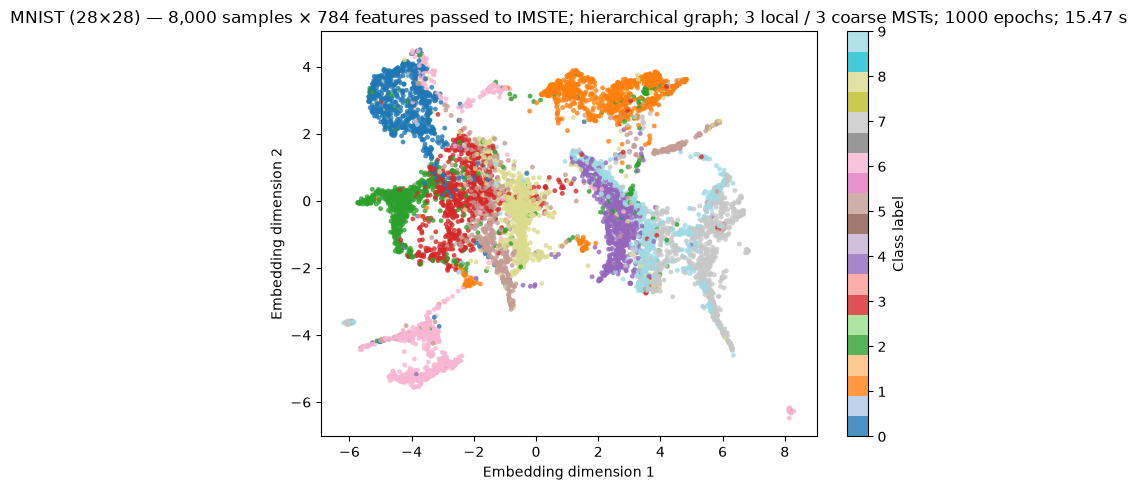

Fitting Fashion-MNIST (28×28) on mps ...
  pipeline completed in 14.69 seconds
  patch preprocessing disabled; IMSTE input: 8,000 samples × 784 features


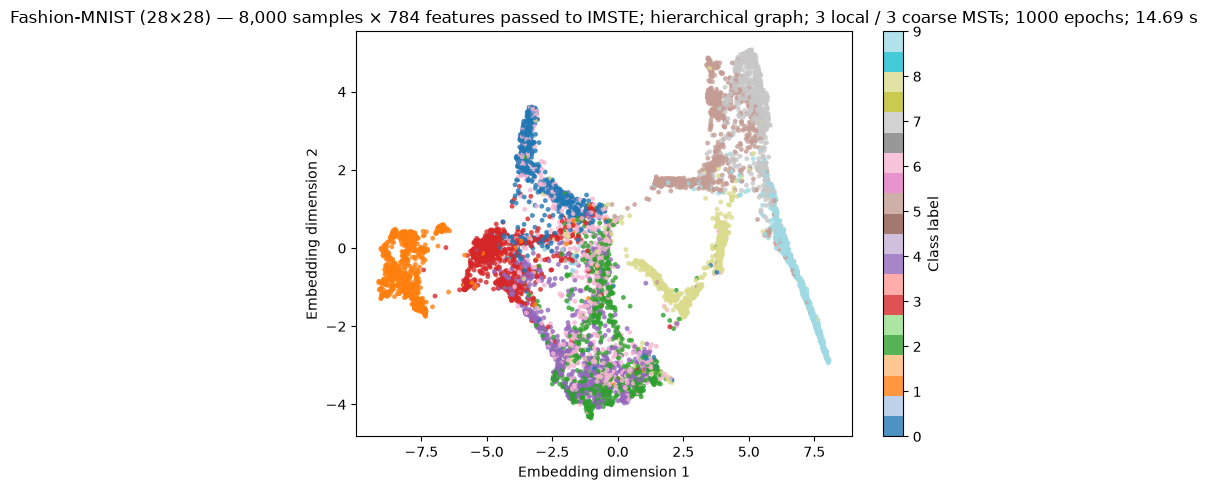

Fitting Kuzushiji-MNIST (28×28) on mps ...
  pipeline completed in 16.73 seconds
  patch preprocessing disabled; IMSTE input: 8,000 samples × 784 features


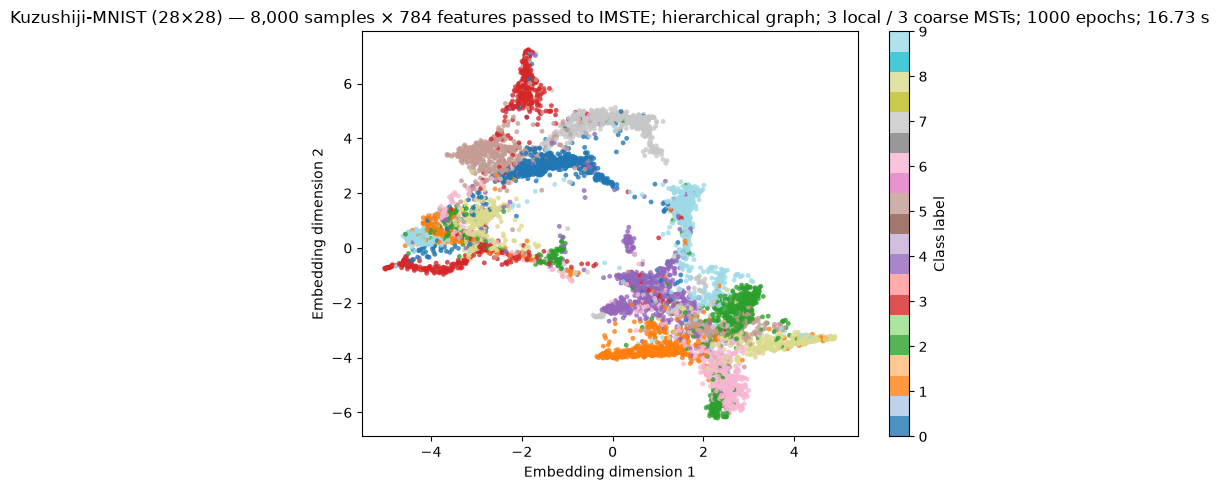

Fitting CIFAR-10 RGB (32×32×3) on mps ...
  pipeline completed in 23.32 seconds
  patch preprocessing disabled; IMSTE input: 8,000 samples × 3,072 features


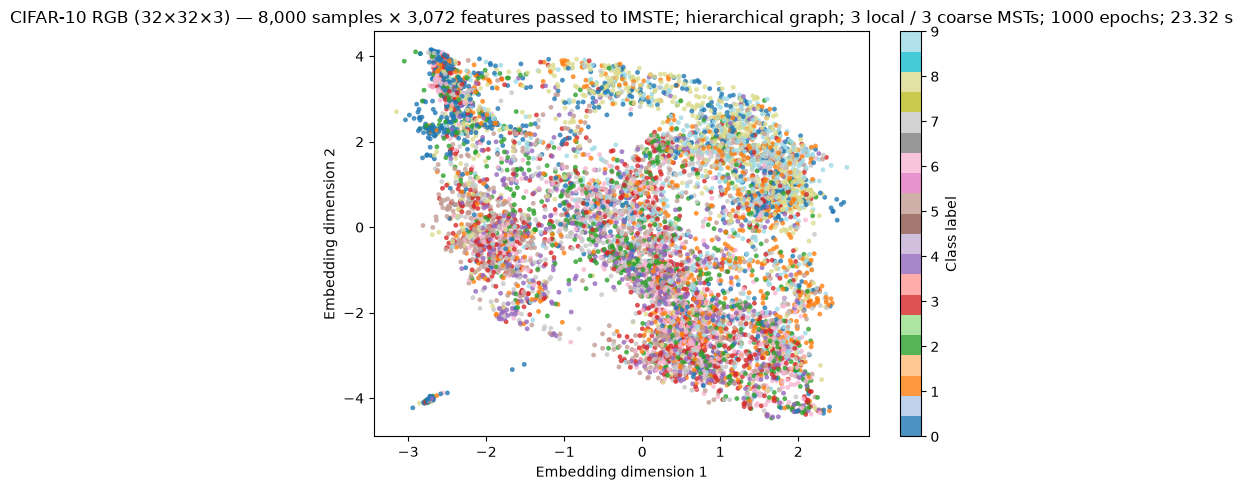

,dataset,samples,input_features,preprocessed_features,patch_grid,padded_patch_shape,patch_features,position_encoding_size,features_per_patch,classes,...,graph_mode,n_clusters,n_coarse_msts,requested_n_coarse_msts,n_local_msts,minibatch_size,n_epochs,unique_graph_edges,seconds,device
0,MNIST (28×28),8000,784,784,None,None,None,None,None,10,...,hierarchical,40,3,3,3,2048,1000,31620,15.465330,mps
1,Fashion-MNIST (28×28),8000,784,784,None,None,None,None,None,10,...,hierarchical,40,3,3,3,2048,1000,31185,14.686992,mps
2,Kuzushiji-MNIST (28×28),8000,784,784,None,None,None,None,None,10,...,hierarchical,40,3,3,3,2048,1000,34177,16.731443,mps
3,CIFAR-10 RGB (32×32×3),8000,3072,3072,None,None,None,None,None,10,...,hierarchical,40,3,3,3,2048,1000,41826,23.324078,mps


In [12]:
from high_dim_mst_gallery import run_high_dim_mst_gallery

# Dataset
MAX_SAMPLES = 8000

#----
# Patch preprocessing
USE_PATCH_PREPROCESSOR = False
N_PATCHES = 5
PATCH_COMPONENTS = 20
POSITION_ENCODING_SIZE = None

#----
# Embedding
N_EPOCHS = 1000

#----
# Graph construction
GRAPH_MODE = "hierarchical"
N_LOCAL_MSTS = 3
N_COARSE_MSTS = 3
N_CLUSTERS = 40

#----
# Runtime
N_JOBS = -1
MINIBATCH_SIZE = 2048

gallery = run_high_dim_mst_gallery(
    max_samples=MAX_SAMPLES,
    n_patches=N_PATCHES,
    patch_n_components=PATCH_COMPONENTS,
    position_encoding_size=POSITION_ENCODING_SIZE,
    use_patch_preprocessor=USE_PATCH_PREPROCESSOR,
    n_epochs=N_EPOCHS,
    graph_mode=GRAPH_MODE,
    n_clusters=N_CLUSTERS,
    n_coarse_msts=N_COARSE_MSTS,
    n_local_msts=N_LOCAL_MSTS,
    n_jobs=N_JOBS,
    minibatch_size=MINIBATCH_SIZE,
)
gallery["summary"]
